# CNN untuk Klasifikasi Jenis Sampah
**Cara Kerja CNN dalam Satu Alur** — Dari foto sampah masuk sampai AI bilang ini plastik. Step by step.

Dataset: [Trash Type Image Dataset](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)  
Kelas: `cardboard`, `glass`, `metal`, `paper`, `plastic`, `trash`

## 📦 1. Install & Import Library

In [1]:
# Install dependencies jika belum ada
!pip install tensorflow matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import classification_report, confusion_matrix

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU tersedia: {tf.config.list_physical_devices('GPU')}")

I0000 00:00:1781776307.293948   30283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781776307.333695   30283 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781776308.518412   30283 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU tersedia: []


E0000 00:00:1781776310.415002   30283 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


## 📁 2. Konfigurasi Path & Parameter

In [3]:
# =============================================
# SESUAIKAN PATH INI DENGAN LOKASI DATASET KAMU
# =============================================
DATASET_DIR = './archive/TrashType_Image_Dataset'  # <-- ganti jika perlu

# Hyperparameter
IMG_SIZE    = (64, 64)      # ukuran gambar (sesuai ilustrasi: 64×64 piksel)
BATCH_SIZE  = 32
EPOCHS      = 30
LEARNING_RATE = 1e-3
VAL_SPLIT   = 0.15          # 15% validasi
TEST_SPLIT  = 0.15          # 15% test (dari sisa setelah val)
SEED        = 42

CLASS_NAMES = sorted(os.listdir(DATASET_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f"Kelas yang ditemukan ({NUM_CLASSES}): {CLASS_NAMES}")

Kelas yang ditemukan (6): ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


## 🔍 3. Eksplorasi Dataset (EDA)

Total gambar: 2527
Distribusi per kelas:
  cardboard   :  403 gambar (15.9%)
  glass       :  501 gambar (19.8%)
  metal       :  410 gambar (16.2%)
  paper       :  594 gambar (23.5%)
  plastic     :  482 gambar (19.1%)
  trash       :  137 gambar (5.4%)


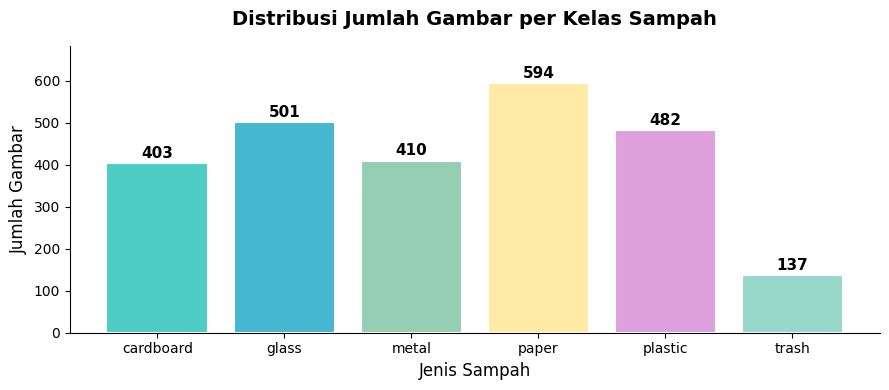

In [4]:
# Hitung jumlah gambar per kelas
class_counts = {}
for cls in CLASS_NAMES:
    cls_path = os.path.join(DATASET_DIR, cls)
    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(images)

total = sum(class_counts.values())
print(f"Total gambar: {total}")
print("Distribusi per kelas:")
for cls, count in class_counts.items():
    print(f"  {cls:12s}: {count:4d} gambar ({count/total*100:.1f}%)")

# Visualisasi distribusi kelas
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD', '#98D8C8']
bars = ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, class_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.set_title('Distribusi Jumlah Gambar per Kelas Sampah', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Jenis Sampah', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
ax.set_ylim(0, max(class_counts.values()) * 1.15)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('distribusi_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

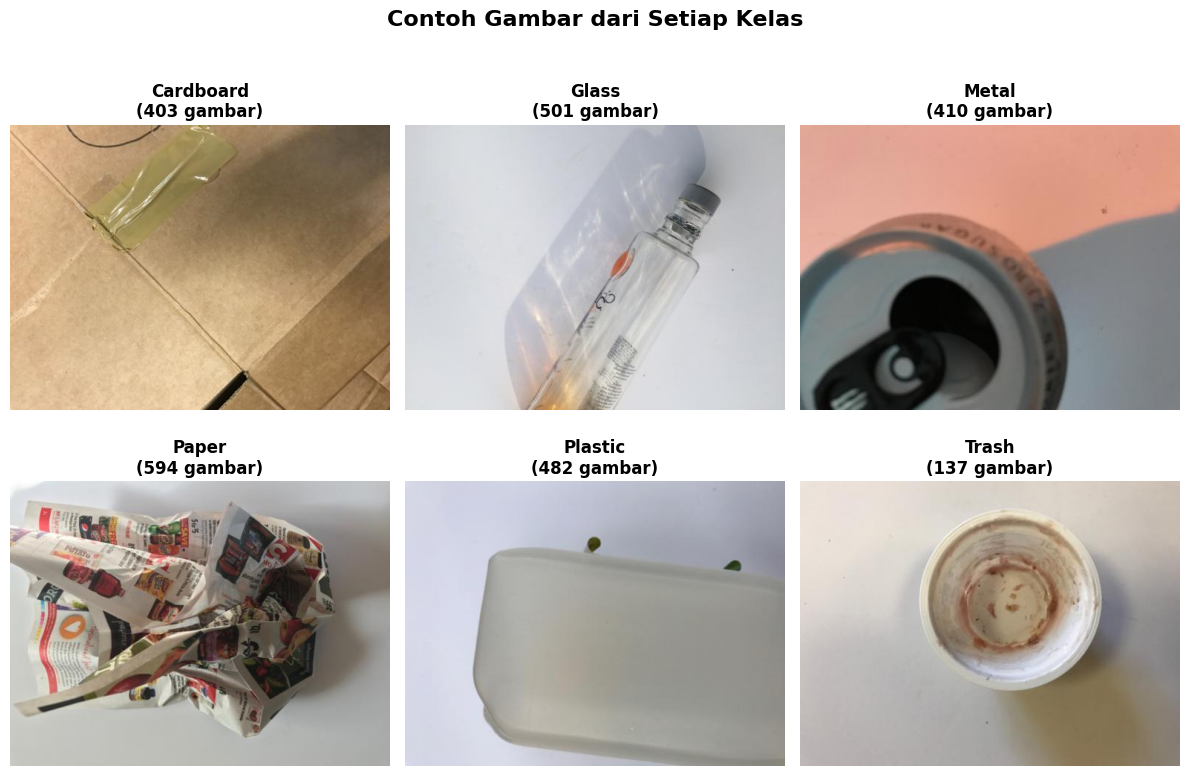

In [5]:
# Tampilkan contoh gambar dari setiap kelas
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(DATASET_DIR, cls)
    img_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    sample_img_path = os.path.join(cls_path, img_files[0])
    img = plt.imread(sample_img_path)
    axes[i].imshow(img)
    axes[i].set_title(f'{cls.capitalize()}\n({class_counts[cls]} gambar)', fontsize=12, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Contoh Gambar dari Setiap Kelas', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('contoh_gambar.png', dpi=150, bbox_inches='tight')
plt.show()

## ⚙️ 4. Preprocessing & Data Augmentation

**STEP 1/7 — Gambar itu cuma angka**  
Foto sampah dipecah jadi grid piksel. Tiap piksel punya nilai 0–255. AI baca angkanya, bukan gambarnya.

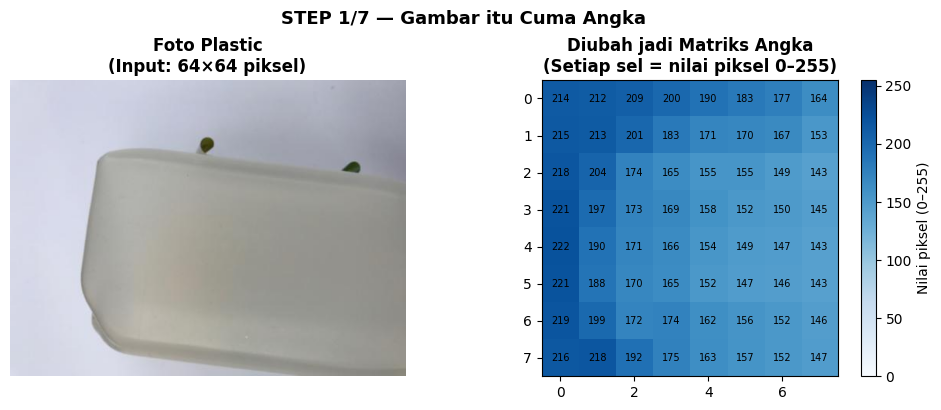

In [6]:
# Demonstrasi: gambar sebagai matriks angka
sample_cls = CLASS_NAMES[4]  # 'plastic'
sample_img_path = os.path.join(DATASET_DIR, sample_cls,
    [f for f in os.listdir(os.path.join(DATASET_DIR, sample_cls)) if f.lower().endswith(('.jpg','.jpeg','.png'))][0])

from PIL import Image
img_pil = Image.open(sample_img_path).resize((8, 8)).convert('L')  # grayscale 8x8
img_arr = np.array(img_pil)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gambar asli
axes[0].imshow(plt.imread(sample_img_path))
axes[0].set_title(f'Foto {sample_cls.capitalize()}\n(Input: 64×64 piksel)', fontweight='bold')
axes[0].axis('off')

# Matriks angka
im = axes[1].imshow(img_arr, cmap='Blues', vmin=0, vmax=255)
axes[1].set_title('Diubah jadi Matriks Angka\n(Setiap sel = nilai piksel 0–255)', fontweight='bold')
for i in range(img_arr.shape[0]):
    for j in range(img_arr.shape[1]):
        axes[1].text(j, i, str(img_arr[i, j]), ha='center', va='center', fontsize=7,
                     color='white' if img_arr[i, j] < 128 else 'black')
plt.colorbar(im, ax=axes[1], label='Nilai piksel (0–255)')

plt.suptitle('STEP 1/7 — Gambar itu Cuma Angka', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('step1_pixel_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# =============================================
# ImageDataGenerator: Preprocessing + Augmentasi
# =============================================

# Generator untuk training (dengan augmentasi)
train_datagen = ImageDataGenerator(
    rescale=1./255,           # normalisasi piksel 0-255 → 0-1
    validation_split=VAL_SPLIT,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generator untuk validasi & test (hanya normalisasi, tanpa augmentasi)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training set
train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

# Validation set
val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f"\nClass indices: {train_gen.class_indices}")
print(f"Training samples  : {train_gen.samples}")
print(f"Validation samples: {val_gen.samples}")

Found 2150 images belonging to 6 classes.
Found 377 images belonging to 6 classes.

Class indices: {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Training samples  : 2150
Validation samples: 377


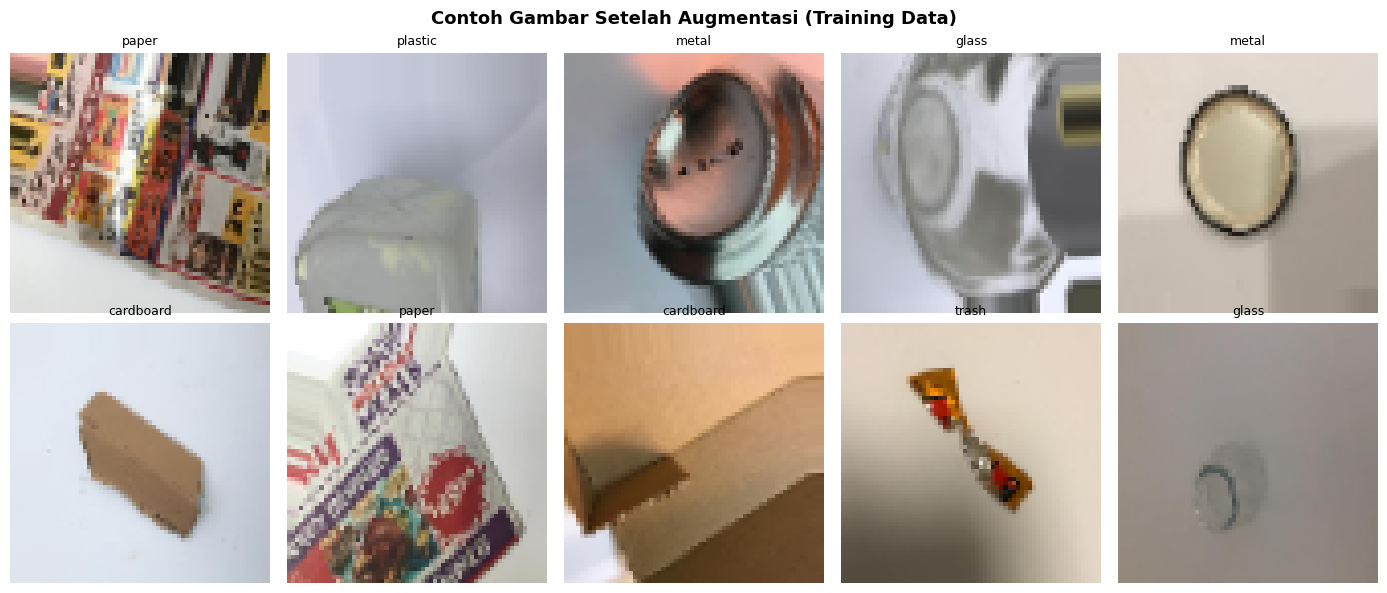

In [8]:
# Visualisasi augmentasi
X_sample, y_sample = next(train_gen)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_sample[i])
    cls_idx = np.argmax(y_sample[i])
    ax.set_title(CLASS_NAMES[cls_idx], fontsize=9)
    ax.axis('off')
plt.suptitle('Contoh Gambar Setelah Augmentasi (Training Data)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏗️ 5. Arsitektur Model CNN

Alur: **Input → Conv → ReLU → Pool → Flatten → FC → Output (Softmax)**

In [9]:
def build_cnn_model(input_shape, num_classes):
    """
    Arsitektur CNN untuk klasifikasi sampah.
    Mengikuti alur: Input → Conv → ReLU → Pool → ... → Flatten → FC → Softmax
    """
    model = keras.Sequential([
        # ── INPUT ──────────────────────────────────────────────────────
        layers.Input(shape=input_shape),

        # ── BLOCK 1: Conv → BN → ReLU → Pool ─────────────────────────
        # STEP 2/7: Filter yang Menggeser
        layers.Conv2D(32, (3, 3), padding='same', use_bias=False, name='conv_block1'),
        layers.BatchNormalization(),
        # STEP 3/7 & 4/7: Feature Map + ReLU (buang negatif)
        layers.Activation('relu', name='relu_block1'),
        # STEP 5/7: Max Pooling (ambil yang penting aja)
        layers.MaxPooling2D((2, 2), name='pool_block1'),
        layers.Dropout(0.25),

        # ── BLOCK 2: Conv → BN → ReLU → Pool ─────────────────────────
        layers.Conv2D(64, (3, 3), padding='same', use_bias=False, name='conv_block2'),
        layers.BatchNormalization(),
        layers.Activation('relu', name='relu_block2'),
        layers.MaxPooling2D((2, 2), name='pool_block2'),
        layers.Dropout(0.25),

        # ── BLOCK 3: Conv → BN → ReLU → Pool ─────────────────────────
        layers.Conv2D(128, (3, 3), padding='same', use_bias=False, name='conv_block3'),
        layers.BatchNormalization(),
        layers.Activation('relu', name='relu_block3'),
        layers.MaxPooling2D((2, 2), name='pool_block3'),
        layers.Dropout(0.30),

        # ── BLOCK 4: Conv → BN → ReLU ────────────────────────────────
        layers.Conv2D(256, (3, 3), padding='same', use_bias=False, name='conv_block4'),
        layers.BatchNormalization(),
        layers.Activation('relu', name='relu_block4'),
        layers.GlobalAveragePooling2D(name='global_avg_pool'),

        # ── STEP 6/7: FLATTEN → FC (Fully Connected) ─────────────────
        layers.Dense(256, use_bias=False, name='fc_256'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.50),

        layers.Dense(128, use_bias=False, name='fc_128'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.40),

        # ── STEP 7/7: OUTPUT dengan Softmax ──────────────────────────
        layers.Dense(num_classes, activation='softmax', name='output_softmax')
    ], name='CNN_TrashClassifier')

    return model


model = build_cnn_model(
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    num_classes=NUM_CLASSES
)

model.summary()

Model: "CNN_TrashClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_block1 (Conv2D)            │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_block1 (Activation)        │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block1 (MaxPooling2D)      │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block2 (Conv2D)            │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_block2 (Activation)        │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block2 (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block3 (Conv2D)            │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_block3 (Activation)        │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_block3 (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block4 (Conv2D)            │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ relu_block4 (Activation)        │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc_256 (Dense)                  │ (None, 256)            │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             

 Total params: 490,470 (1.87 MB)

 Trainable params: 488,742 (1.86 MB)

 Non-trainable params: 1,728 (6.75 KB)

In [10]:
# Hitung parameter
total_params = model.count_params()
print(f"Total parameter: {total_params:,}")
print(f"Trainable      : {sum([np.prod(v.shape) for v in model.trainable_weights]):,}")

Total parameter: 490,470
Trainable      : 488,742


## 🎯 6. Compile & Training

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Model siap ditraining!")
print(f"  Epochs       : {EPOCHS}")
print(f"  Batch size   : {BATCH_SIZE}")
print(f"  Learning rate: {LEARNING_RATE}")

Model siap ditraining!
  Epochs       : 30
  Batch size   : 32
  Learning rate: 0.001


In [12]:
# Training!
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30


I0000 00:00:1781776349.576188   30283 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.3235 - loss: 1.8206
Epoch 1: val_accuracy improved from None to 0.19098, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
68/68 ━━━━━━━━━━━━━━━━━━━━ 15s 186ms/step - accuracy: 0.3842 - loss: 1.6704 - val_accuracy: 0.1910 - val_loss: 1.7769 - learning_rate: 0.0010
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4452 - loss: 1.5116
Epoch 2: val_accuracy did not improve from 0.19098
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 156ms/step - accuracy: 0.4698 - loss: 1.4345 - val_accuracy: 0.1910 - val_loss: 2.4087 - learning_rate: 0.0010
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.4910 - loss: 1.3484
Epoch 3: val_accuracy did not improve from 0.19098
68/68 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.5037 - loss: 1.3061 - val_accuracy: 0.1910 - val_loss: 2.5561 - learning_rate: 0.0010
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.5068 - loss: 1.3277
E

## 📈 7. Visualisasi Training History

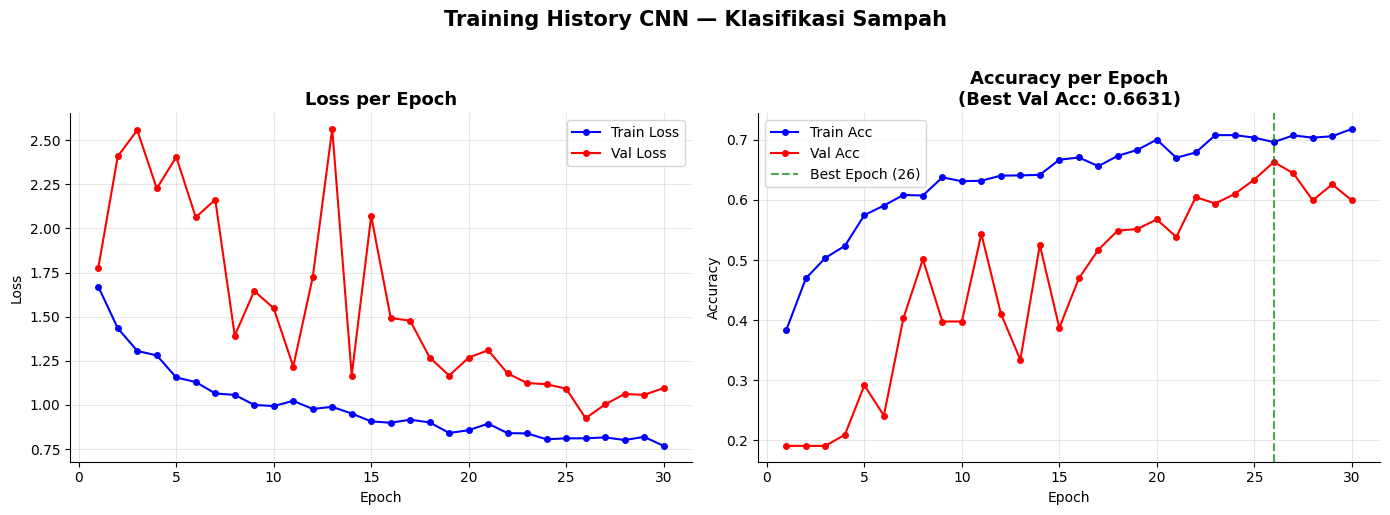

Best Val Accuracy: 0.6631 pada Epoch 26


In [13]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs_ran = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0].plot(epochs_ran, history.history['loss'],     'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs_ran, history.history['val_loss'], 'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title('Loss per Epoch', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].spines[['top', 'right']].set_visible(False)

    # Accuracy
    axes[1].plot(epochs_ran, history.history['accuracy'],     'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs_ran, history.history['val_accuracy'], 'r-o', label='Val Acc',   markersize=4)
    best_val_acc = max(history.history['val_accuracy'])
    best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
    axes[1].axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    axes[1].set_title(f'Accuracy per Epoch\n(Best Val Acc: {best_val_acc:.4f})', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    axes[1].spines[['top', 'right']].set_visible(False)

    plt.suptitle('Training History CNN — Klasifikasi Sampah', fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Best Val Accuracy: {best_val_acc:.4f} pada Epoch {best_epoch}")

plot_training_history(history)

## 📊 8. Evaluasi Model

In [15]:
# Load best model
best_model = keras.models.load_model('best_model.keras')

# Evaluasi di validation set
val_loss, val_acc = best_model.evaluate(val_gen, verbose=1)
print(f"\nValidation Loss    : {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f} ({val_acc*100:.2f}%)")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6737 - loss: 0.9221

Validation Loss    : 0.9221
Validation Accuracy: 0.6737 (67.37%)


In [16]:
# Prediksi untuk confusion matrix dan classification report
val_gen.reset()
y_pred_proba = best_model.predict(val_gen, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = val_gen.classes

print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step

=== Classification Report ===
              precision    recall  f1-score   support

   cardboard     0.7733    0.9667    0.8593        60
       glass     0.5926    0.6400    0.6154        75
       metal     0.9231    0.3934    0.5517        61
       paper     0.7222    0.8764    0.7919        89
     plastic     0.5375    0.5972    0.5658        72
       trash     0.7143    0.2500    0.3704        20

    accuracy                         0.6790       377
   macro avg     0.7105    0.6206    0.6257       377
weighted avg     0.7014    0.6790    0.6631       377



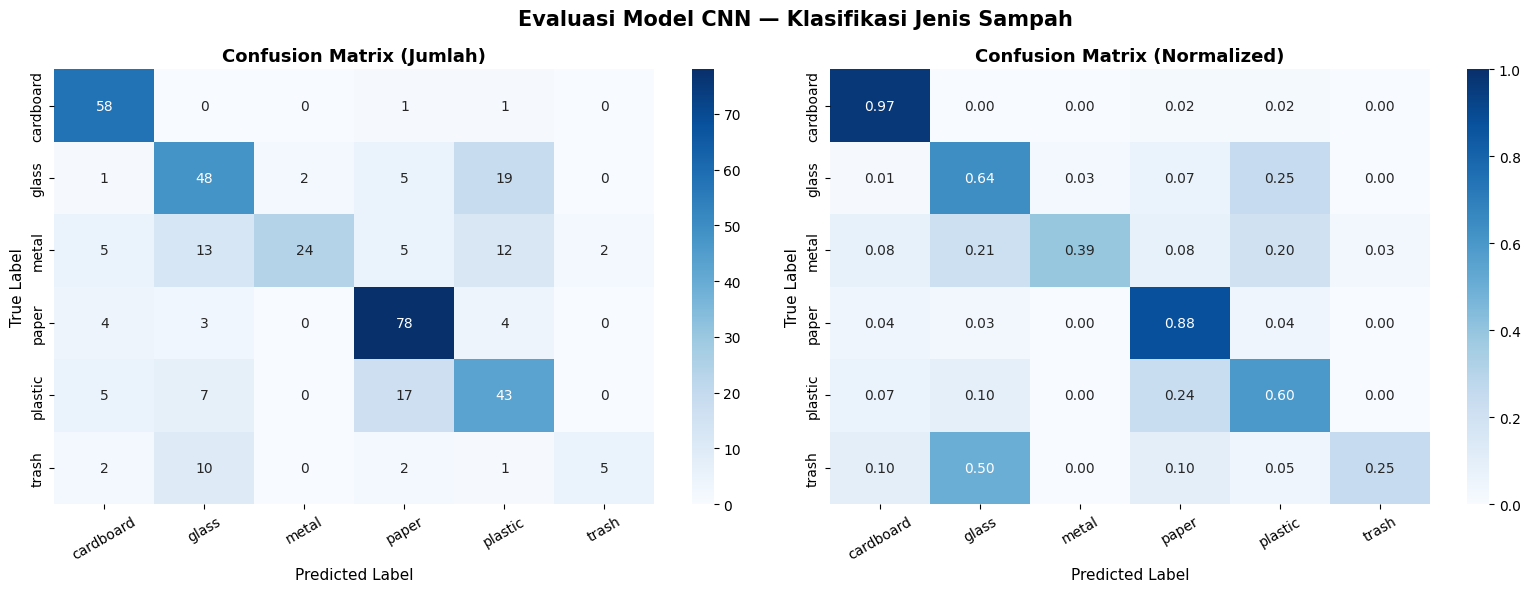

In [17]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalisasi per baris

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw count
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Jumlah)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)

# Normalized
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1],
            vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Evaluasi Model CNN — Klasifikasi Jenis Sampah', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 🔮 9. Prediksi Gambar Baru

**STEP 7/7 — AI bilang: ...!**  
Output Softmax menghasilkan probabilitas untuk setiap kategori sampah. Nilai tertinggi = prediksi akhir.

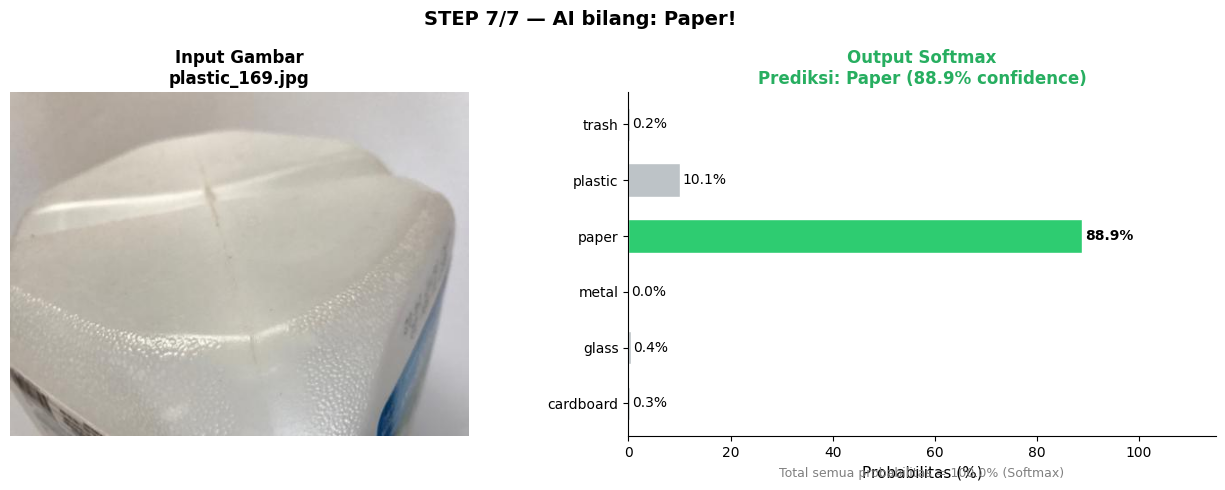


Prediksi : PAPER (88.88% confidence)
Probabilitas semua kelas:
  paper       : 88.88% ✓
  plastic     : 10.15%
  glass       : 0.41%
  cardboard   : 0.31%
  trash       : 0.22%
  metal       : 0.03%


('paper', np.float32(0.8888385))

In [ ]:
def predict_image(model, img_path, class_names, img_size=(64, 64)):
    """
    Prediksi jenis sampah dari satu gambar.
    Menampilkan probabilitas per kelas (seperti ilustrasi STEP 7/7).
    """
    from PIL import Image as PILImage

    # Load & preprocess
    img = PILImage.open(img_path).convert('RGB').resize(img_size)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # tambah dimensi batch

    # Prediksi
    proba = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(proba)
    pred_class = class_names[pred_idx]
    confidence = proba[pred_idx]

    # Visualisasi (mirip tampilan STEP 7/7)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Gambar
    axes[0].imshow(PILImage.open(img_path))
    axes[0].set_title(f'Input Gambar\n{os.path.basename(img_path)}', fontweight='bold')
    axes[0].axis('off')

    # Bar chart probabilitas (Softmax output)
    colors_bar = ['#2ECC71' if i == pred_idx else '#BDC3C7' for i in range(len(class_names))]
    bars = axes[1].barh(class_names, proba * 100, color=colors_bar, edgecolor='white', height=0.6)

    for bar, p in zip(bars, proba):
        axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                     f'{p*100:.1f}%', va='center', fontsize=10,
                     fontweight='bold' if p == confidence else 'normal')

    axes[1].set_xlim(0, 115)
    axes[1].set_xlabel('Probabilitas (%)', fontsize=11)
    axes[1].set_title(f'Output Softmax\nPrediksi: {pred_class.capitalize()} ({confidence*100:.1f}% confidence)',
                      fontsize=12, fontweight='bold', color='#27AE60')
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].text(0.5, -0.12, f'Total semua probabilitas = {sum(proba)*100:.1f}% (Softmax)',
                 transform=axes[1].transAxes, ha='center', fontsize=9, color='gray')

    plt.suptitle('STEP 7/7 — AI bilang: ' + pred_class.capitalize() + '!',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('prediksi_output.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\nPrediksi : {pred_class.upper()} ({confidence*100:.2f}% confidence)")
    print("Probabilitas semua kelas:")
    for cls, p in sorted(zip(class_names, proba), key=lambda x: -x[1]):
        marker = " ✓" if cls == pred_class else ""
        print(f"  {cls:12s}: {p*100:.2f}%{marker}")

    return pred_class, confidence

CLASS_NAMES
# Coba prediksi dengan salah satu gambar dari dataset
sample_class = CLASS_NAMES[4]  # 'plastic'
sample_dir = os.path.join(DATASET_DIR, sample_class)
sample_files = [f for f in os.listdir(sample_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
test_img_path = os.path.join(sample_dir, sample_files[5])  # ambil gambar ke-6

predict_image(best_model, test_img_path, CLASS_NAMES, IMG_SIZE)

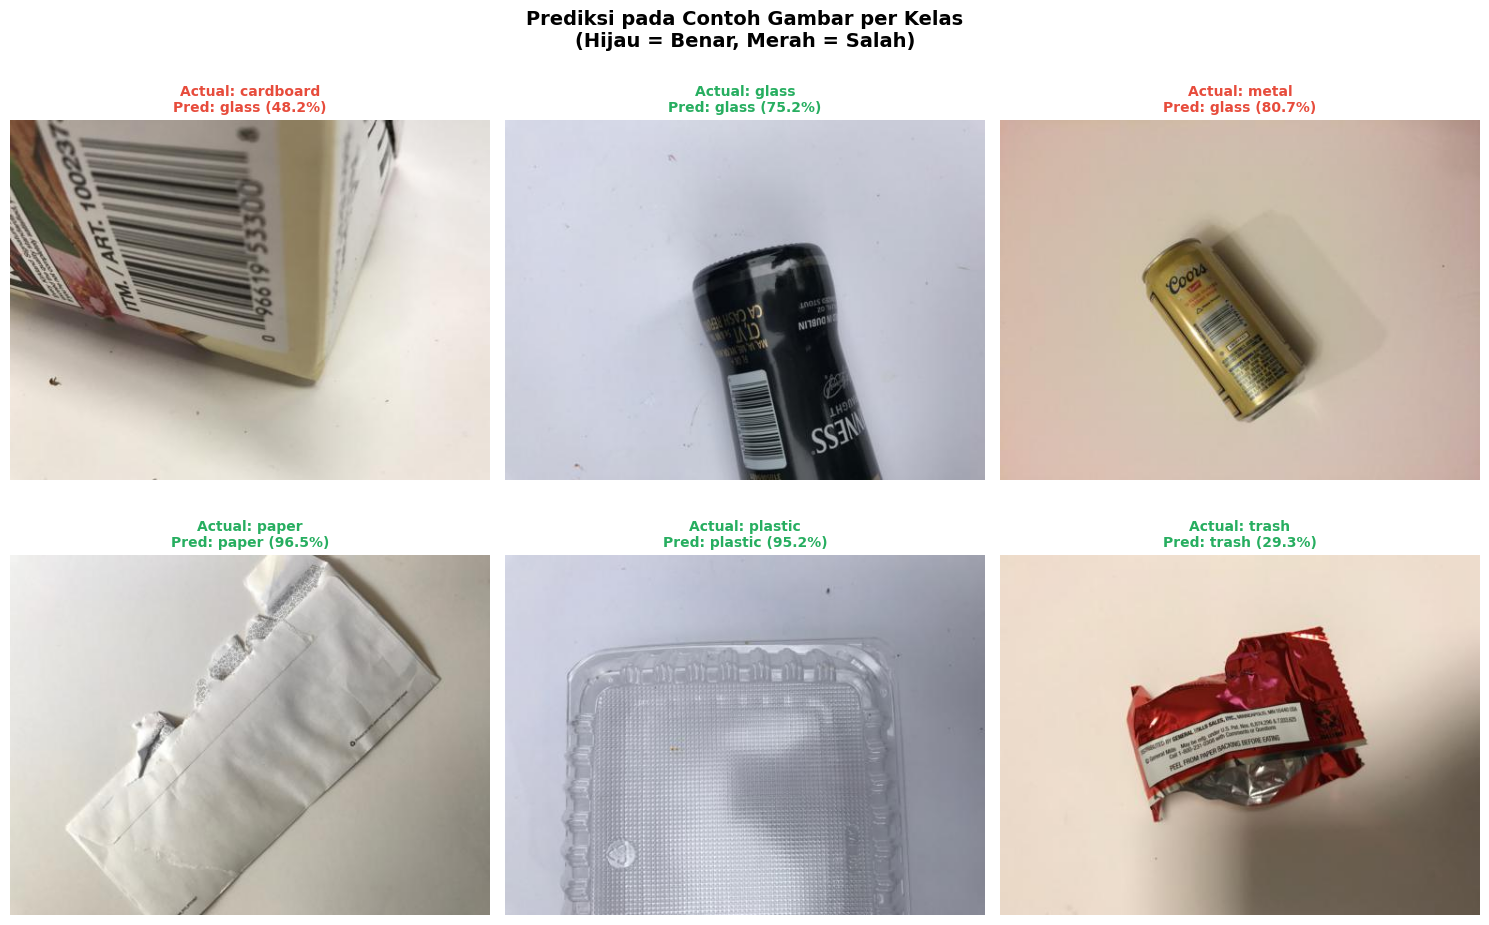

In [19]:
# Prediksi pada beberapa gambar sekaligus
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cls in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(DATASET_DIR, cls)
    files = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    test_path = os.path.join(cls_dir, files[10])  # ambil gambar ke-11

    from PIL import Image as PILImage
    img = PILImage.open(test_path).convert('RGB').resize(IMG_SIZE)
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)
    proba = best_model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(proba)
    pred_cls = CLASS_NAMES[pred_idx]
    confidence = proba[pred_idx]

    axes[i].imshow(PILImage.open(test_path))
    color = '#27AE60' if pred_cls == cls else '#E74C3C'
    axes[i].set_title(
        f"Actual: {cls}\nPred: {pred_cls} ({confidence*100:.1f}%)",
        fontsize=10, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.suptitle('Prediksi pada Contoh Gambar per Kelas\n(Hijau = Benar, Merah = Salah)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('prediksi_grid.png', dpi=150, bbox_inches='tight')
plt.show()

## 🗺️ 10. Ringkasan Alur CNN

In [20]:
# Ringkasan hasil akhir
print("=" * 55)
print("       RINGKASAN ALUR CNN — KLASIFIKASI SAMPAH")
print("=" * 55)
steps = [
    ("Input",        "Gambar dipecah jadi matriks angka 0–255"),
    ("Conv",         "Filter mendeteksi tepi, bentuk, dan pola"),
    ("ReLU",         "Buang nilai negatif, fokus sinyal penting"),
    ("Pool",         "Kompres ukuran, pertahankan info penting"),
    ("Flatten",      "Ubah 2D jadi array 1D"),
    ("FC + Softmax", "Keputusan akhir dengan probabilitas"),
]
for step, desc in steps:
    print(f"  {step:15s} → {desc}")
print("=" * 55)
print(f"  Val Accuracy : {val_acc*100:.2f}%")
print(f"  Num Classes  : {NUM_CLASSES} ({', '.join(CLASS_NAMES)})")
print(f"  Image Size   : {IMG_SIZE[0]}×{IMG_SIZE[1]} piksel")
print("=" * 55)

       RINGKASAN ALUR CNN — KLASIFIKASI SAMPAH
  Input           → Gambar dipecah jadi matriks angka 0–255
  Conv            → Filter mendeteksi tepi, bentuk, dan pola
  ReLU            → Buang nilai negatif, fokus sinyal penting
  Pool            → Kompres ukuran, pertahankan info penting
  Flatten         → Ubah 2D jadi array 1D
  FC + Softmax    → Keputusan akhir dengan probabilitas
  Val Accuracy : 67.37%
  Num Classes  : 6 (cardboard, glass, metal, paper, plastic, trash)
  Image Size   : 64×64 piksel


In [21]:
# Simpan model akhir
best_model.save('CNN_TrashClassifier_final.keras')
print("Model disimpan: CNN_TrashClassifier_final.keras")

Model disimpan: CNN_TrashClassifier_final.keras
